# Progetto della parte finale del corso di "Data Mining" da 12 CFU

## MODULE 1: Outliers

* Identify the top 1% outliers: adopt at least three different methods from
  different families (i.e., density-based, angle-based…) and compare the
  results.
  * ISOLATION FOREST, LOF, CBLOF
* Visualize the outliers in a 2D or 3D scatter plot using at least one
  dimensionality reduction technique.
  * PCA
* Deal with the outliers in a way you see fit, e.g., by removing them from the
  dataset or by treating the anomalous variables as missing values and
  employing replacement techniques. In this second case, you should check
  that the outliers are not outliers anymore. Justify your choices in every
  step.

---

### Informazioni Generali

* **Corso:** Data Mining
* **Università:** Università di Pisa
* **Anno Accademico:** 2024/2025

### Autore

* **Studente:** Giuseppe Muschetta
* **Matricola:** 564026

### Dataset Utilizzato

* **Nome:** Extended IMDb Dataset (Tabulare)
* **Descrizione:** Dataset tabulare contenente circa 150,000 record con informazioni relative ai titoli cinematografici.#%% md


In [1]:
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from pyod.models.lof import LOF
from pyod.models.cblof import CBLOF
from pyod.models.iforest import IsolationForest

# --- IMPOSTAZIONI GLOBALI PER I GRAFICI ---
plt.style.use("dark_background")
sns.set_theme(
    style="darkgrid", context="notebook", palette="icefire",
    font="sans-serif", font_scale=1.1
)
plt.rcParams.update({
    'axes.labelweight': 'bold', 'axes.titleweight': 'bold', 'axes.edgecolor': 'white',
    'axes.labelcolor': 'white', 'xtick.color': 'lightgray', 'ytick.color': 'lightgray',
    'text.color': 'white', 'figure.facecolor': '#111111', 'axes.facecolor': '#111111',
    'savefig.facecolor': '#111111'
})
print("✅ Impostazioni grafiche caricate.")

# --- CREAZIONE DIRECTORY PER I PLOT ---
plots_dir = 'plots_outlier_detection/'
os.makedirs(plots_dir, exist_ok=True)
print(f"✅ Directory per i grafici '{plots_dir}' pronta.")

# --- CARICAMENTO DEL DATASET PREPARATO ---
dataset_dir = 'dataset/'
dataset_name = 'imdb_prepared.csv'
try:
    data = pd.read_csv(os.path.join(dataset_dir, dataset_name))
    print(f"✅ Dataset preparato caricato: {data.shape[0]} righe, {data.shape[1]} colonne.")
except FileNotFoundError as e:
    print(f"❌ Errore: File non trovato. Assicurati di aver eseguito il Modulo 0 e salvato '{dataset_name}'.")
    exit(1)

# --- SELEZIONE FEATURE PER L'ANALISI ---
# L'analisi va fatta SOLO sulle feature numeriche trasformate (_proc)
proc_columns = [col for col in data.columns if col.endswith('_proc')]
X = data[proc_columns]
print(f"✅ Analisi degli outlier basata su {X.shape[1]} feature '_proc'.")

✅ Impostazioni grafiche caricate.
✅ Directory per i grafici 'plots_outlier_detection/' pronta.
✅ Dataset preparato caricato: 149521 righe, 109 colonne.
✅ Analisi degli outlier basata su 20 feature '_proc'.


### Rilevamento Outliers con PyOD

In [2]:
import time
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from pyod.models.cblof import CBLOF

# Livello di contaminazione (1% di outlier)
contamination_level = 0.01

print(f"\n--- Inizio Rilevamento Outlier (contamination = {contamination_level*100}%) ---")

# --- Modello 1: Isolation Forest (da Scikit-learn) ---
start_time = time.time()
iso_forest = IsolationForest(contamination=contamination_level, random_state=42, n_jobs=-1)
# .fit_predict() restituisce -1 per outlier, 1 per inlier
iso_labels = iso_forest.fit_predict(X)
iso_scores = iso_forest.decision_function(X)
# Uniformiamo l'output: 1 per outlier, 0 per inlier
data['outlier_isolation_forest'] = (iso_labels == -1).astype(int)
data['score_isolation_forest'] = iso_scores
end_time = time.time()
print(f"✅ Isolation Forest (sklearn) completato in {end_time - start_time:.2f} secondi.")

# --- Modello 2: Local Outlier Factor (da Scikit-learn) ---
start_time = time.time()
# novelty=False è necessario per usare fit_predict sui dati di training
lof = LocalOutlierFactor(n_neighbors=30, contamination=contamination_level, novelty=False, n_jobs=-1)
# .fit_predict() restituisce -1 per outlier, 1 per inlier
lof_labels = lof.fit_predict(X)
# .negative_outlier_factor_ contiene gli score (più è negativo, più è anomalo)
lof_scores = lof.negative_outlier_factor_
# Uniformiamo l'output: 1 per outlier, 0 per inlier
data['outlier_lof'] = (lof_labels == -1).astype(int)
data['score_lof'] = lof_scores
end_time = time.time()
print(f"✅ Local Outlier Factor (sklearn) completato in {end_time - start_time:.2f} secondi.")

# --- Modello 3: CBLOF (da PyOD) ---
start_time = time.time()
cblof = CBLOF(n_clusters=15, contamination=contamination_level, random_state=42, n_jobs=-1)
# .fit() popola .labels_ e .decision_scores_
cblof.fit(X)
# L'output di PyOD è già 1 per outlier, 0 per inlier
data['outlier_cblof'] = cblof.labels_
data['score_cblof'] = cblof.decision_scores_
end_time = time.time()
print(f"✅ CBLOF (pyod) completato in {end_time - start_time:.2f} secondi.")


--- Inizio Rilevamento Outlier (contamination = 1.0%) ---
✅ Isolation Forest (sklearn) completato in 1.27 secondi.
✅ Local Outlier Factor (sklearn) completato in 6.56 secondi.
✅ CBLOF (pyod) completato in 0.99 secondi.


#### Analisi comparativa dei risultati

In [3]:
# --- CONFRONTO DEI RISULTATI ---
print("\n--- Riepilogo Outlier Rilevati ---")

# Calcolo dell'accordo tra i metodi (somma delle etichette, dove 1 è un outlier)
data['outlier_agreement'] = data['outlier_isolation_forest'] + data['outlier_lof'] + data['outlier_cblof']

# Creazione di un report di riepilogo
agreement_counts = data['outlier_agreement'].value_counts().sort_index()

print(f"Numero di outlier per singolo metodo:")
print(f"  - Isolation Forest: {data['outlier_isolation_forest'].sum()}")
print(f"  - LOF:                {data['outlier_lof'].sum()}")
print(f"  - CBLOF:              {data['outlier_cblof'].sum()}")
print("\nAccordo tra i metodi:")
print(f"  - Punti non considerati outlier:                  {agreement_counts.get(0, 0)}")
print(f"  - Outlier identificati da 1 solo metodo:          {agreement_counts.get(1, 0)}")
print(f"  - Outlier identificati da 2 metodi (consenso):    {agreement_counts.get(2, 0)}")
print(f"  - Outlier identificati da 3 metodi (consenso forte): {agreement_counts.get(3, 0)}")

# Definiamo la nostra etichetta finale di outlier (accordo di almeno 2 metodi)
data['is_outlier_final'] = (data['outlier_agreement'] >= 2).astype(int)
total_outliers = data['is_outlier_final'].sum()
percentage = (total_outliers / len(data)) * 100

print("\n--------------------------------------------------------------------")
print(f"➡️ TOTALE OUTLIER DA RIMUOVERE (accordo >= 2): {total_outliers} ({percentage:.2f}%)")
print("--------------------------------------------------------------------")


--- Riepilogo Outlier Rilevati ---
Numero di outlier per singolo metodo:
  - Isolation Forest: 1496
  - LOF:                1496
  - CBLOF:              1496

Accordo tra i metodi:
  - Punti non considerati outlier:                  146205
  - Outlier identificati da 1 solo metodo:          2227
  - Outlier identificati da 2 metodi (consenso):    1006
  - Outlier identificati da 3 metodi (consenso forte): 83

--------------------------------------------------------------------
➡️ TOTALE OUTLIER DA RIMUOVERE (accordo >= 2): 1089 (0.73%)
--------------------------------------------------------------------


#### Visualizzazione comparativa con PCA

--- Esecuzione della PCA per la visualizzazione ---
Componenti PCA calcolate e aggiunte al DataFrame.
✅ Grafico di confronto salvato in 'plots_outlier_detection/pca_outlier_comparison.png'.


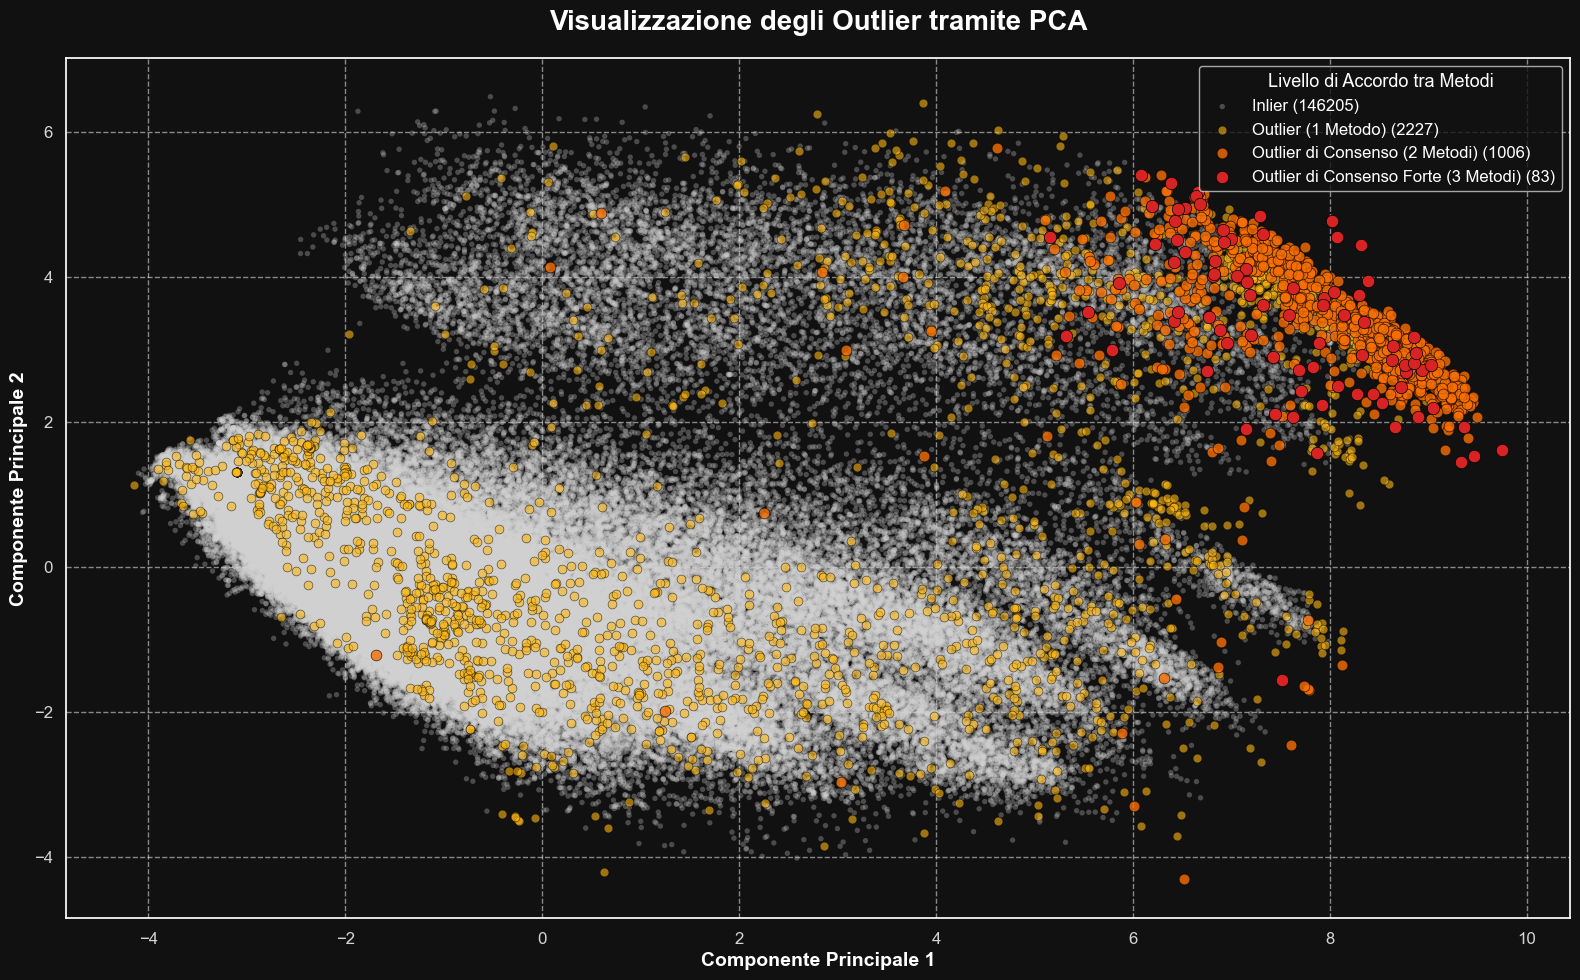

In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. Riduzione della Dimensionalità con PCA ---
print("--- Esecuzione della PCA per la visualizzazione ---")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
data['pca1'] = X_pca[:, 0]
data['pca2'] = X_pca[:, 1]
print("Componenti PCA calcolate e aggiunte al DataFrame.")

# --- 2. Creazione del Grafico 2D Riepilogativo ---
plt.figure(figsize=(16, 10))

# Mappatura di colori, dimensioni e trasparenza per una leggibilità ottimale
colors = {0: 'lightgray', 1: '#FDB813', 2: '#F86F03', 3: '#D72323'} # Grigio, Giallo, Arancione, Rosso
labels = {
    0: f"Inlier ({agreement_counts.get(0, 0)})",
    1: f"Outlier (1 Metodo) ({agreement_counts.get(1, 0)})",
    2: f"Outlier di Consenso (2 Metodi) ({agreement_counts.get(2, 0)})",
    3: f"Outlier di Consenso Forte (3 Metodi) ({agreement_counts.get(3, 0)})"
}
alphas = {0: 0.3, 1: 0.6, 2: 0.8, 3: 1.0}
sizes = {0: 15, 1: 40, 2: 60, 3: 80}

# Plottiamo ogni gruppo separatamente per controllare lo stile
for agreement_level, group_data in data.groupby('outlier_agreement'):
    plt.scatter(
        group_data['pca1'], group_data['pca2'],
        c=colors[agreement_level],
        s=sizes[agreement_level],
        alpha=alphas[agreement_level],
        label=labels[agreement_level],
        edgecolor='k' if agreement_level > 0 else 'none',
        linewidth=0.5
    )

plt.title("Visualizzazione degli Outlier tramite PCA", fontsize=20, fontweight='bold', pad=20)
plt.xlabel("Componente Principale 1", fontsize=14)
plt.ylabel("Componente Principale 2", fontsize=14)
legend = plt.legend(title="Livello di Accordo tra Metodi", fontsize=12)
plt.setp(legend.get_title(),fontsize='13')
plt.grid(True, linestyle='--', alpha=0.5)

# Salvataggio del grafico
plot_path = os.path.join(plots_dir, "pca_outlier_comparison.png")
plt.tight_layout()
plt.savefig(plot_path, dpi=300)
print(f"✅ Grafico di confronto salvato in '{plot_path}'.")
plt.show()

#### Dashboard di Visualizzazione per Singolo Metodo

--- Creazione del dashboard di confronto per singolo metodo ---
✅ Dashboard salvato in 'plots_outlier_detection/pca_dashboard_by_method.png'.


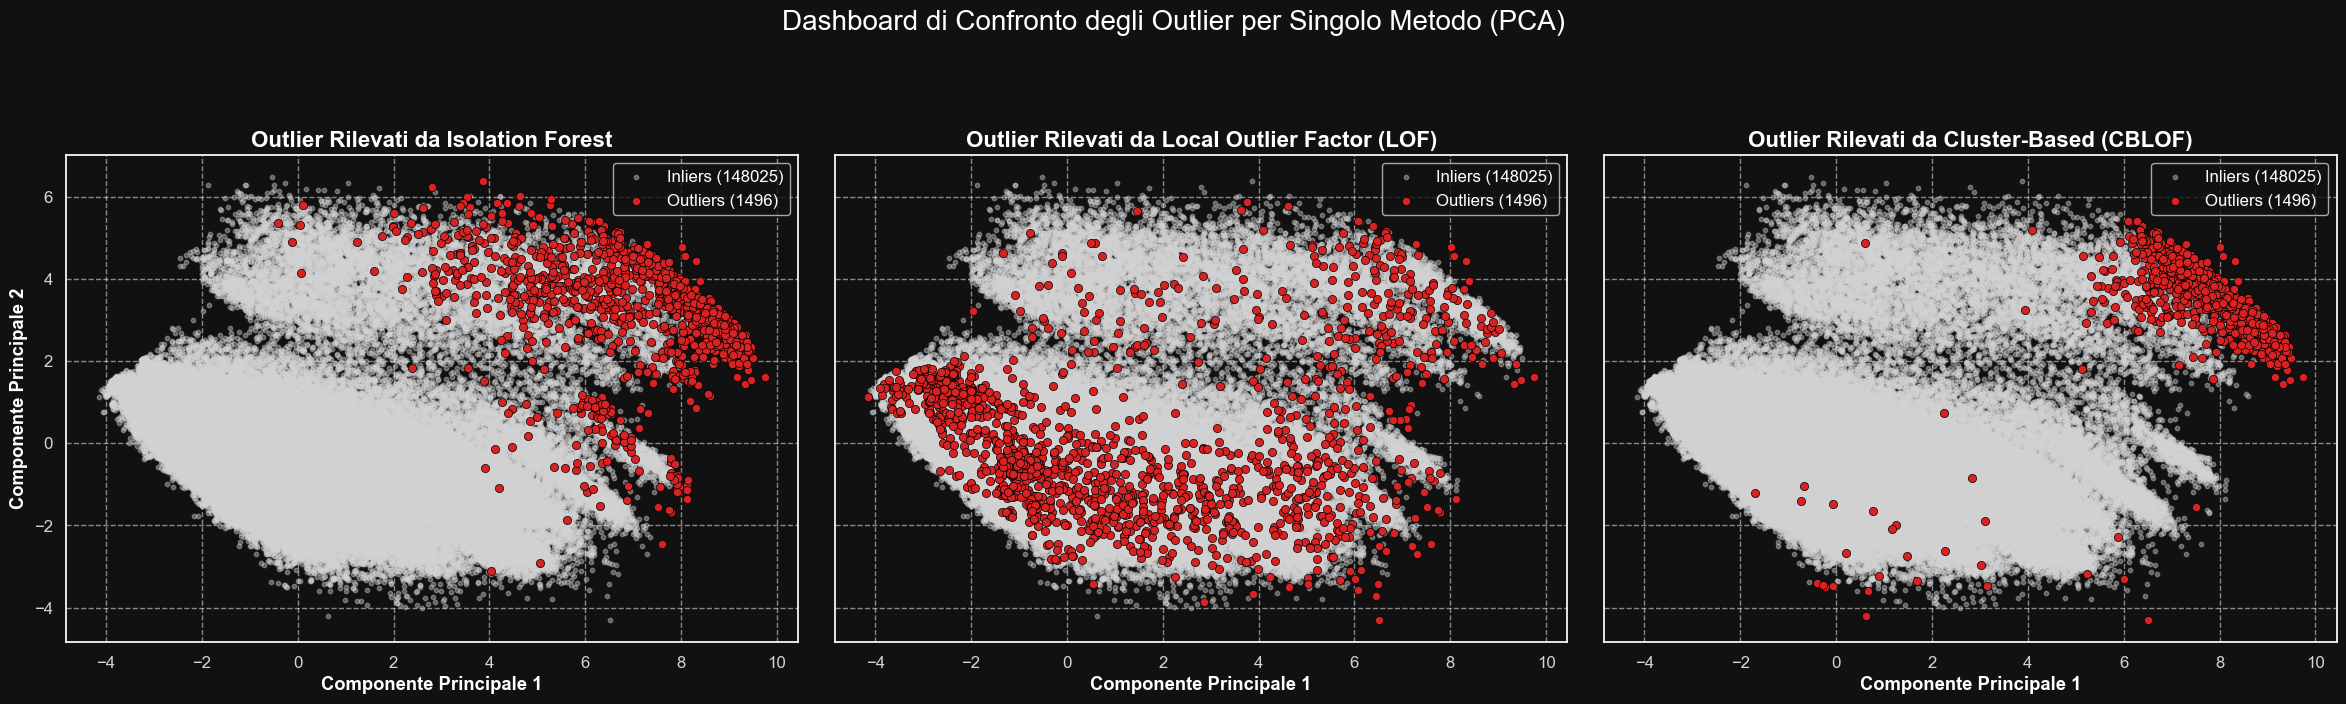

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. Creazione del Dashboard 1x3 ---
print("--- Creazione del dashboard di confronto per singolo metodo ---")
fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharex=True, sharey=True)

# Liste per iterare in modo pulito
outlier_methods_cols = ['outlier_isolation_forest', 'outlier_lof', 'outlier_cblof']
titles = ['Isolation Forest', 'Local Outlier Factor (LOF)', 'Cluster-Based (CBLOF)']

# --- 2. Creazione di ogni singolo grafico ---
for ax, method_col, title in zip(axes, outlier_methods_cols, titles):
    # Separiamo inlier e outlier SECONDO IL METODO CORRENTE
    inliers = data[data[method_col] == 0]
    outliers = data[data[method_col] == 1]

    # Plottiamo prima gli inlier come sfondo
    ax.scatter(inliers['pca1'], inliers['pca2'], c='lightgray', s=10, alpha=0.4, label=f'Inliers ({len(inliers)})')
    # E poi gli outlier in evidenza
    ax.scatter(outliers['pca1'], outliers['pca2'], c='#D72323', s=35, edgecolor='k', linewidth=0.5, label=f'Outliers ({len(outliers)})')

    ax.set_title(f"Outlier Rilevati da {title}", fontsize=16, fontweight='bold')
    ax.set_xlabel("Componente Principale 1")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

# Impostiamo il label dell'asse Y solo per il primo grafico per pulizia
axes[0].set_ylabel("Componente Principale 2")

plt.suptitle("Dashboard di Confronto degli Outlier per Singolo Metodo (PCA)", fontsize=20, y=1.03)
plt.tight_layout(pad=2.0)

# --- 3. Salvataggio del Grafico ---
plot_path_dashboard = os.path.join(plots_dir, "pca_dashboard_by_method.png")
plt.savefig(plot_path_dashboard, dpi=300)
print(f"✅ Dashboard salvato in '{plot_path_dashboard}'.")
plt.show()

#### Ispezione outliers di consenso

In [6]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# --- 1. Filtraggio degli Outlier di Consenso ---
print("--- Ispezione dei Top 5 Outlier di Consenso ---")
consensus_outliers_df = data[data['outlier_agreement'] >= 2].copy()

# --- 2. Creazione di uno Score di Consenso Normalizzato ---
scaler = MinMaxScaler()

# Normalizziamo gli score (ricorda che per LOF e CBLOF più alto è peggio, per IForest più basso è peggio)
consensus_outliers_df['score_lof_norm'] = scaler.fit_transform(consensus_outliers_df[['score_lof']])
consensus_outliers_df['score_cblof_norm'] = scaler.fit_transform(consensus_outliers_df[['score_cblof']])
# Per Isolation Forest, score più bassi sono più anomali, quindi invertiamo la scala (1 - score normalizzato)
consensus_outliers_df['score_iso_norm'] = 1 - scaler.fit_transform(consensus_outliers_df[['score_isolation_forest']])

# Calcoliamo lo score di consenso come media
consensus_outliers_df['consensus_score'] = consensus_outliers_df[['score_lof_norm', 'score_cblof_norm', 'score_iso_norm']].mean(axis=1)

# --- 3. Ordinamento e Visualizzazione ---
top_5_outliers = consensus_outliers_df.sort_values(by='consensus_score', ascending=False).head(10)

print(f"I 5 outlier con lo score di anomalia di consenso più alto sono:")

# Per visualizzare tutte le colonne, trasponiamo l'output
pd.set_option('display.max_columns', None)
display(top_5_outliers.drop(columns=[col for col in data.columns if '_proc' in col]).T) # Rimuoviamo le _proc per leggibilità

--- Ispezione dei Top 5 Outlier di Consenso ---
I 5 outlier con lo score di anomalia di consenso più alto sono:


,74558,30811,121247,76581,99521,98207,142363,22889,16547,79545
originalTitle,Sons of Anarchy,Scrubs,Unbreakable Kimmy Schmidt,Only Murders in the Building,Last Man Standing,Veep,Dollface,Family Guy,Buffy the Vampire Slayer,Jujutsu Kaisen
rating,"(8, 9]","(8, 9]","(7, 8]","(8, 9]","(7, 8]","(8, 9]","(7, 8]","(8, 9]","(8, 9]","(8, 9]"
startYear,2008,2001,2015,2021,2011,2012,2019,1999,1997,2020
endYear,2014,2010,2019,\N,2021,2019,2022,\N,2003,\N
runtimeMinutes,45.0,22.0,30.0,30.0,30.0,28.0,29.0,22.0,44.0,24.0
...,...,...,...,...,...,...,...,...,...,...
pca2,3.28887,3.186454,4.035559,4.082614,4.073369,3.283624,4.222868,3.138551,3.253416,4.052505
score_lof_norm,0.96847,0.973341,0.985746,0.96882,0.979342,0.968778,0.992536,0.97572,0.98951,0.917251
score_cblof_norm,0.352952,0.354551,0.376307,0.38619,0.369064,0.357174,0.363662,0.360393,0.349398,0.397966
score_iso_norm,0.95858,0.945305,0.910068,0.915114,0.915114,0.937375,0.90503,0.922472,0.919117,0.941273


In [7]:
top_5_outliers

,originalTitle,rating,startYear,endYear,runtimeMinutes,awardWins,numVotes,totalImages,totalVideos,totalCredits,criticReviewsTotal,awardNominationsExcludeWins,numRegions,userReviewsTotal,companiesNumber,averageRating,writerCredits,directorsCredits,quotesTotal,type_movie,type_short,type_tvEpisode,type_tvMiniSeries,type_tvMovie,type_tvSeries,type_tvShort,type_tvSpecial,type_video,type_videoGame,genres_drama,genres_comedy,genres_action,genres_animation,genres_adventure,genres_short,genres_documentary,genres_crime,genres_family,genres_romance,genres_mystery,genres_fantasy,genres_horror,genres_reality-tv,genres_thriller,genres_music,genres_history,genres_sci-fi,genres_talk-show,genres_game-show,countryOfOrigin_us,countryOfOrigin_gb,countryOfOrigin_jp,countryOfOrigin_fr,countryOfOrigin_ca,countryOfOrigin_in,countryOfOrigin_de,countryOfOrigin_it,countryOfOrigin_es,countryOfOrigin_au,regions_us,regions_gb,regions_fr,regions_jp,regions_de,regions_es,regions_it,regions_in,regions_pt,regions_ca,regions_xww,regions_br,regions_au,regions_pl,regions_ru,regions_hu,regions_gr,regions_se,regions_fi,regions_mx,soundMixes_mono,soundMixes_stereo,soundMixes_dolby_digital,soundMixes_silent,soundMixes_dolby,winRate,contentRichness,logPopularityScore,criticUserRatio,hasWriterAndDirector,startYear_proc,runtimeMinutes_proc,awardWins_proc,numVotes_proc,totalImages_proc,totalVideos_proc,totalCredits_proc,criticReviewsTotal_proc,awardNominationsExcludeWins_proc,numRegions_proc,userReviewsTotal_proc,companiesNumber_proc,averageRating_proc,writerCredits_proc,directorsCredits_proc,quotesTotal_proc,winRate_proc,contentRichness_proc,logPopularityScore_proc,criticUserRatio_proc,outlier_isolation_forest,score_isolation_forest,outlier_lof,score_lof,outlier_cblof,score_cblof,outlier_agreement,is_outlier_final,pca1,pca2,score_lof_norm,score_cblof_norm,score_iso_norm,consensus_score
74558,Sons of Anarchy,"(8, 9]",2008,2014,45.0,12,330347,3453,29,1734,95,58,42,636,75,8.6,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,0,1,0,0,1,0,0,0.171429,5217,19.302312,0.706909,0,0.400185,-0.060509,3.335687,2.029712,2.100650,3.39205,2.880511,2.011797,3.155946,2.180491,1.919616,2.293908,1.447757,-1.33565,-1.722096,2.378430,3.269512,2.976981,1.807247,2.166089,1,-0.054620,0,-1.025976,1,8.359395,2,1,8.496714,3.288870,0.968470,0.352952,0.958580,0.760001
30811,Scrubs,"(8, 9]",2001,2010,22.0,33,273420,458,91,1853,68,136,44,423,81,8.4,0,0,270,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,0,1,1,1,0,1,1,0,0,0.195266,2672,18.715208,0.699883,0,-0.009046,-1.027813,3.335687,2.029641,2.070566,3.39205,2.900255,2.011671,3.155946,2.191625,1.918958,2.316049,1.239852,-1.33565,-1.722096,2.544094,3.299821,2.848876,1.797251,2.165038,1,-0.052222,0,-1.014012,1,8.374118,2,1,8.384636,3.186454,0.973341,0.354551,0.945305,0.757732
121247,Unbreakable Kimmy Schmidt,"(7, 8]",2015,2019,30.0,26,79865,425,18,1539,53,98,36,222,22,7.5,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,0,1,0,1,1,1,1,1,1,1,0,1,0,1,1,0,0,0.209677,1982,16.904864,0.737721,0,0.889669,-0.651435,3.335687,2.028557,2.068199,3.39205,2.843471,2.011496,3.155946,2.141332,1.916961,1.781416,0.382696,-1.33565,-1.722096,-0.400731,3.311952,2.775917,1.762089,2.170250,1,-0.045855,0,-0.983542,1,8.574467,2,1,7.713072,4.035559,0.985746,0.376307,0.910068,0.757374
76581,Only Murders in the Building,"(8, 9]",2021,\N,30.0,64,167064,419,6,982,131,262,39,1107,25,8.1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,0,1,0,1,0,0,1,0,0,0.196319,1407,19.147385,0.696517,0,1.374014,-0.651435,3.335687,2.029369,2.067732,3.39205,2.684329,2.011858,3.155946,2.162109,1.920119,1.851202,0.939390,-1.33565,-1.722096,-0.400731,3.300837,2.677437,1.804669,2.164520,1,-0.046767,0,-1.025117,1,8.665473,2,1,7.631685,4.082614,0.968820,

#### Rimozione outliers di consenso

In [8]:
import os

# --- 1. Definizione e Salvataggio degli Outlier da Rimuovere ---
print("--- Trattamento degli Outlier di Consenso ---")

# La nostra regola: consideriamo outlier i punti con accordo >= 2
outliers_to_remove_mask = data['outlier_agreement'] >= 2
outliers_to_remove_df = data[outliers_to_remove_mask]
num_outliers_removed = len(outliers_to_remove_df)
percentage_removed = (num_outliers_removed / len(data)) * 100

print(f"Identificati {num_outliers_removed} outlier di consenso da rimuovere ({percentage_removed:.2f}% del dataset).")

# Salviamo gli outlier in un file separato per tracciabilità
outliers_path = os.path.join(dataset_dir, 'imdb_outliers_removed.csv')
outliers_to_remove_df.to_csv(outliers_path, index=False)
print(f"✅ Outlier salvati per ispezione in '{outliers_path}'.")


# --- 2. Rimozione e Pulizia del DataFrame ---
initial_shape = data.shape
data_cleaned = data[~outliers_to_remove_mask].copy()

# Rimuoviamo le colonne di supporto che non servono più
support_cols = [col for col in data.columns if 'outlier_' in col or 'score_' in col or 'pca' in col or 'is_outlier' in col]
data_cleaned.drop(columns=support_cols, inplace=True)

print("\nRimozione degli outlier completata.")
print(f"Shape del DataFrame prima della rimozione: {initial_shape}")
print(f"Shape del DataFrame dopo la rimozione:    {data_cleaned.shape}")

# --- 3. Salvataggio del Dataset Pulito ---
cleaned_path = os.path.join(dataset_dir, 'imdb_prepared_no_outliers.csv')
data_cleaned.to_csv(cleaned_path, index=False)
print(f"✅ Dataset pulito salvato e pronto per il prossimo modulo in '{cleaned_path}'.")

--- Trattamento degli Outlier di Consenso ---
Identificati 1089 outlier di consenso da rimuovere (0.73% del dataset).
✅ Outlier salvati per ispezione in 'dataset/imdb_outliers_removed.csv'.

Rimozione degli outlier completata.
Shape del DataFrame prima della rimozione: (149521, 119)
Shape del DataFrame dopo la rimozione:    (148432, 109)
✅ Dataset pulito salvato e pronto per il prossimo modulo in 'dataset/imdb_prepared_no_outliers.csv'.


In [9]:
data_cleaned.head()

,originalTitle,rating,startYear,endYear,runtimeMinutes,awardWins,numVotes,totalImages,totalVideos,totalCredits,criticReviewsTotal,awardNominationsExcludeWins,numRegions,userReviewsTotal,companiesNumber,averageRating,writerCredits,directorsCredits,quotesTotal,type_movie,type_short,type_tvEpisode,type_tvMiniSeries,type_tvMovie,type_tvSeries,type_tvShort,type_tvSpecial,type_video,type_videoGame,genres_drama,genres_comedy,genres_action,genres_animation,genres_adventure,genres_short,genres_documentary,genres_crime,genres_family,genres_romance,genres_mystery,genres_fantasy,genres_horror,genres_reality-tv,genres_thriller,genres_music,genres_history,genres_sci-fi,genres_talk-show,genres_game-show,countryOfOrigin_us,countryOfOrigin_gb,countryOfOrigin_jp,countryOfOrigin_fr,countryOfOrigin_ca,countryOfOrigin_in,countryOfOrigin_de,countryOfOrigin_it,countryOfOrigin_es,countryOfOrigin_au,regions_us,regions_gb,regions_fr,regions_jp,regions_de,regions_es,regions_it,regions_in,regions_pt,regions_ca,regions_xww,regions_br,regions_au,regions_pl,regions_ru,regions_hu,regions_gr,regions_se,regions_fi,regions_mx,soundMixes_mono,soundMixes_stereo,soundMixes_dolby_digital,soundMixes_silent,soundMixes_dolby,winRate,contentRichness,logPopularityScore,criticUserRatio,hasWriterAndDirector,startYear_proc,runtimeMinutes_proc,awardWins_proc,numVotes_proc,totalImages_proc,totalVideos_proc,totalCredits_proc,criticReviewsTotal_proc,awardNominationsExcludeWins_proc,numRegions_proc,userReviewsTotal_proc,companiesNumber_proc,averageRating_proc,writerCredits_proc,directorsCredits_proc,quotesTotal_proc,winRate_proc,contentRichness_proc,logPopularityScore_proc,criticUserRatio_proc
0,Carmencita,"(5, 6]",1894,\N,1.0,0,2089,2,0,4,3,0,7,16,3,5.7,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,1,0,0.0,6,10.588905,0.489301,0,-2.328935,-2.218492,-0.299937,1.952604,0.175777,-0.294835,-1.561607,1.887143,-0.317291,1.436996,1.836167,0.168822,-0.919474,-1.33565,0.244167,-0.400731,-0.299870,-1.486015,1.552267,2.102152
1,Un bon bock,"(5, 6]",1892,\N,12.0,0,183,2,0,2,0,0,6,1,0,5.4,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0.0,4,5.214936,0.000000,0,-2.349904,-1.558192,-0.299937,1.204695,0.175777,-0.294835,-1.706100,-0.572805,-0.317291,1.337103,0.777289,-1.530391,-1.099138,-1.33565,0.244167,-0.400731,-0.299870,-1.611139,1.082526,-0.465842
2,Chinese Opium Den,"(4, 5]",1894,\N,1.0,0,195,1,0,1,0,0,5,0,1,5.0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0.0,2,0.000000,0.000000,0,-2.328935,-2.218492,-0.299937,1.246122,-0.347872,-0.294835,-1.780375,-0.572805,-0.317291,1.210830,-0.737922,-0.766296,-1.328129,-1.33565,0.244167,-0.400731,-0.299870,-1.740513,-0.863379,-0.465842
3,Edison Kinetoscopic Record of a Sneeze,"(5, 6]",1894,\N,1.0,1,2237,3,0,4,2,0,6,20,6,5.4,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,1.0,7,10.803954,0.360849,0,-2.328935,-2.218492,3.332135,1.958049,0.503730,-0.294835,-1.561607,1.777884,-0.317291,1.337103,1.855327,0.821188,-1.099138,-1.33565,0.244167,-0.400731,3.347882,-1.425032,1.562992,1.995890
4,L'arrivée d'un train à La Ciotat,"(7, 8]",1896,\N,1.0,0,13115,12,0,11,16,0,21,66,5,7.4,0,2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,1,1,1,1,0,0,1,1,1,0,1,1,1,0,0,1,0,0,0,0,1,0,0.0,23,13.888232,0.673822,0,-2.307632,-2.218492,-0.299937,2.019425,1.427826,-0.294835,-1.097614,2.006642,-0.317291,1.973326,1.904733,0.654420,0.296101,-1.33565,1.435843,-0.400731,-0.299870,-0.587026,1.683882,2.160761
